# NLP Practice Exercise — Amazon Product Reviews

In this exercise you will practice the same NLP pipeline you learned in the practical task, but on a **new dataset**: a collection of Amazon product reviews.

Work through each cell. Some cells have **TODO** comments where you need to write the code yourself. A hint is provided for each one.

---

## Step 0 — Imports & Downloads

Run this cell as-is. It sets up everything you need.

In [1]:
import pandas as pd
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\usama\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\usama\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\usama\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Step 1 — Create the Dataset

Run this cell to create a small Amazon-style review dataset directly in memory.

In [2]:
reviews = [
    ("This product is absolutely amazing! Works perfectly and arrived quickly.", 5),
    ("Terrible quality. Broke after two days. Do NOT buy this.", 1),
    ("Decent product for the price. Not the best, but does the job.", 3),
    ("I love this! Best purchase I've made all year. Highly recommend.", 5),
    ("Packaging was damaged and the item had scratches. Very disappointed.", 2),
    ("Works great, easy to set up, and looks nice. Very happy with it.", 5),
    ("It's okay. Nothing special. Would not buy again.", 2),
    ("Exceeded my expectations! Fast shipping, great quality, perfect fit.", 5),
    ("Product stopped working after a week. Customer support was not helpful.", 1),
    ("Pretty good overall. A few minor issues but nothing major.", 3),
    ("Fantastic product! My kids absolutely love it. Great value for money.", 5),
    ("Not as described. The color was completely different from the picture.", 1),
    ("Good quality material. Comfortable and durable. Will buy again.", 4),
    ("Average product. Does what it says but nothing extraordinary.", 3),
    ("Shipping was fast, product is solid. Happy with my purchase overall.", 4),
]

data = pd.DataFrame(reviews, columns=['Review', 'Rating'])
print(data.info())
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  15 non-null     object
 1   Rating  15 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 372.0+ bytes
None


,Review,Rating
0,This product is absolutely amazing! Works perf...,5
1,Terrible quality. Broke after two days. Do NOT...,1
2,"Decent product for the price. Not the best, bu...",3
3,I love this! Best purchase I've made all year....,5
4,Packaging was damaged and the item had scratch...,2


## Step 2 — Explore the Data

Look at the first review and check what a raw review looks like.

In [3]:
# TODO: Print the first review from the 'Review' column
# Hint: use data['Review'][0]

data['Review'][0]

'This product is absolutely amazing! Works perfectly and arrived quickly.'

In [4]:
# TODO: Print the average rating
# Hint: use data['Rating'].mean()
data['Rating'].mean()

np.float64(3.2666666666666666)

## Step 3 — Lowercase the Reviews

Create a new column `Review_lowercase` with all text in lowercase.

In [10]:
# TODO: Lowercase the 'Review' column and store in 'Review_lowercase'
# Hint: use .str.lower()
data['Review_lowercase'] =  data['Review'].str.lower()

data.head()

,Review,Rating,Review_lowercase
0,This product is absolutely amazing! Works perf...,5,this product is absolutely amazing! works perf...
1,Terrible quality. Broke after two days. Do NOT...,1,terrible quality. broke after two days. do not...
2,"Decent product for the price. Not the best, bu...",3,"decent product for the price. not the best, bu..."
3,I love this! Best purchase I've made all year....,5,i love this! best purchase i've made all year....
4,Packaging was damaged and the item had scratch...,2,packaging was damaged and the item had scratch...


## Step 4 — Remove Stopwords

Load English stopwords — but keep the word **'not'** (it matters for sentiment in reviews!).

Then create a new column `Review_no_stopwords`.

In [12]:
# TODO: Load English stopwords and remove 'not' from the list
# Hint: stopwords.words('english') then .remove('not')
en_stopwords = stopwords.words('english')
en_stopwords.remove("not")

# TODO: Create 'Review_no_stopwords' by filtering out stopwords from 'Review_lowercase'
# Hint: use .apply(lambda x: ' '.join([word for word in x.split() if word not in en_stopwords]))
data['Review_no_stopwords'] = data['Review_lowercase'].apply(lambda review: ' '.join([word for word in review.split() if word not in en_stopwords]))


print(data['Review_no_stopwords'][0])

product absolutely amazing! works perfectly arrived quickly.


## Step 5 — Remove Punctuation

Use regex to remove all punctuation from the reviews.

Store the result in `Review_clean`.

In [15]:
# TODO: Remove all punctuation using re.sub
# Hint: use re.sub(r'([^\w\s])','',x) inside a lambda
data['Review_clean'] = data['Review_no_stopwords'].apply(lambda x: re.sub(r"([^\w\s])",'',x))


print(data['Review_clean'][0])

product absolutely amazing works perfectly arrived quickly


## Step 6 — Tokenize

Split each cleaned review into a list of individual word tokens.

Store the result in `Review_tokenized`.

In [18]:
# TODO: Tokenize 'Review_clean' using word_tokenize
# Hint: use .apply(lambda x: word_tokenize(x))
data['Review_tokenized'] = data['Review_clean'].apply(lambda x: word_tokenize(x) )


print(data['Review_tokenized'][0])

['product', 'absolutely', 'amazing', 'works', 'perfectly', 'arrived', 'quickly']


## Step 7 — Stemming

Apply **PorterStemmer** to reduce each token to its root form.

Store the result in `Review_stemmed`.

In [19]:
# TODO: Create a PorterStemmer instance and apply it to each token list
# Hint: Ps = PorterStemmer() then use lambda tokens: [Ps.stem(t) for t in tokens]
Ps = PorterStemmer()

data['Review_stemmed'] = data['Review_tokenized'].apply(lambda tokens: [Ps.stem(token) for token in tokens])


print(data['Review_stemmed'][0])

['product', 'absolut', 'amaz', 'work', 'perfectli', 'arriv', 'quickli']


## Step 8 — Lemmatization

Apply **WordNetLemmatizer** to get proper dictionary forms of words.

Store the result in `Review_lemmatized`.

In [20]:
# TODO: Create a WordNetLemmatizer and apply it to each token list
# Hint: lemmatizer = WordNetLemmatizer() then lambda tokens: [lemmatizer.lemmatize(t) for t in tokens]
lemmatizer = WordNetLemmatizer()

data['Review_lemmatized'] = data["Review_tokenized"].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])


print(data['Review_lemmatized'][0])

['product', 'absolutely', 'amazing', 'work', 'perfectly', 'arrived', 'quickly']


## Step 9 — Compare Stemming vs Lemmatization

Look at the same review after stemming and after lemmatization side by side. Notice the differences.

In [21]:
# TODO: Print Review_stemmed[1] and Review_lemmatized[1] and compare them
# Which words look different between the two?
print("Stemmed:    ", data['Review_stemmed'][1])
print("Lemmatized: ", data['Review_lemmatized'][1])

Stemmed:     ['terribl', 'qualiti', 'broke', 'two', 'day', 'not', 'buy', 'thi']
Lemmatized:  ['terrible', 'quality', 'broke', 'two', 'day', 'not', 'buy', 'this']


## Step 10 — Flatten All Tokens

Combine all lemmatized token lists into a single flat list called `all_tokens`.

In [22]:
# TODO: Flatten the list of token lists into one big list
# Hint: sum(data['Review_lemmatized'], [])
all_tokens = sum(data['Review_lemmatized'], [])


print(f"Total tokens: {len(all_tokens)}")
print(all_tokens[:20])

Total tokens: 107
['product', 'absolutely', 'amazing', 'work', 'perfectly', 'arrived', 'quickly', 'terrible', 'quality', 'broke', 'two', 'day', 'not', 'buy', 'this', 'decent', 'product', 'price', 'not', 'best']


## Step 11 — Unigrams (top 10 single words)

Find the most frequent single words across all reviews and plot them.

In [23]:
# TODO: Create unigrams using nltk.ngrams with n=1 and count with value_counts()
# Hint: pd.Series(nltk.ngrams(all_tokens, 1)).value_counts()
unigrams = pd.Series(nltk.ngrams(all_tokens,1)).value_counts()

print(unigrams[:10])

(product,)       6
(not,)           5
(nothing,)       3
(great,)         3
(quality,)       3
(buy,)           3
(best,)          2
(again,)         2
(absolutely,)    2
(it,)            2
Name: count, dtype: int64


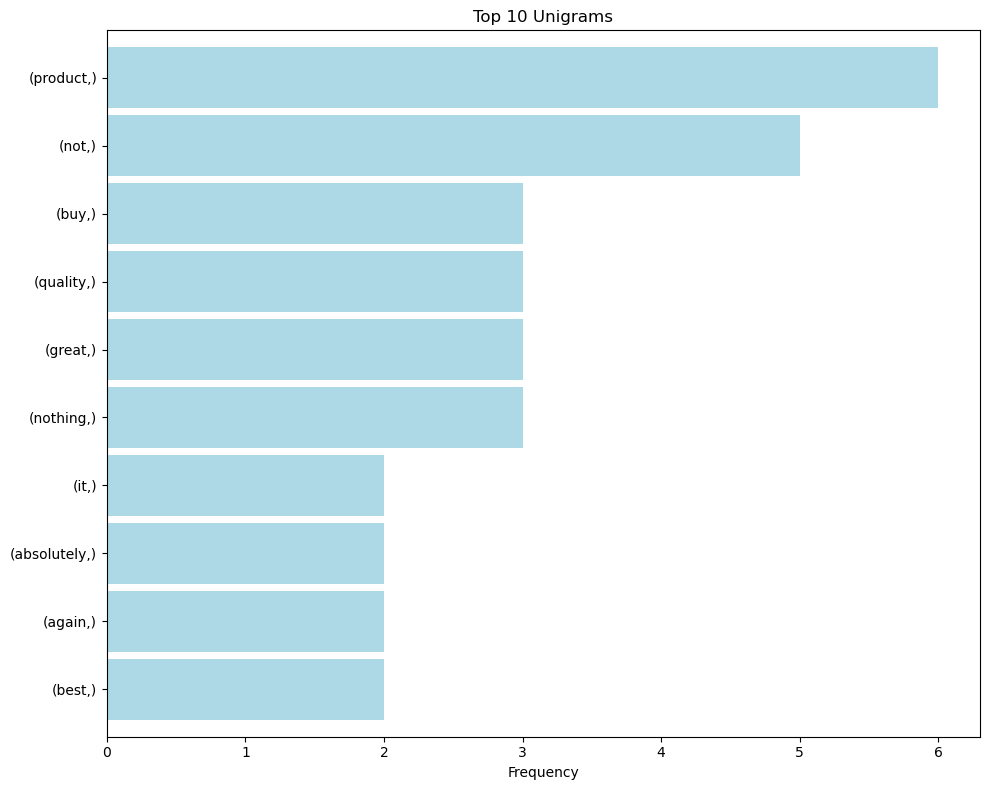

In [24]:
# TODO: Plot the top 10 unigrams as a horizontal bar chart
# Hint: unigrams[0:10].sort_values().plot.barh(...)
unigrams[0:10].sort_values().plot.barh(color= "lightblue", width= 0.9, figsize = (10,8) )
plt.title('Top 10 Unigrams')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

## Step 12 — Bigrams (top 10 word pairs)

Find the most frequent two-word combinations.

In [25]:
# TODO: Create bigrams using nltk.ngrams with n=2
bigrams = pd.Series(nltk.ngrams(all_tokens,2)).value_counts()

print(bigrams[:10])

(buy, again)             2
(not, buy)               2
(product, absolutely)    1
(good, overall)          1
(love, it)               1
(absolutely, love)       1
(kid, absolutely)        1
(product, kid)           1
(fantastic, product)     1
(major, fantastic)       1
Name: count, dtype: int64


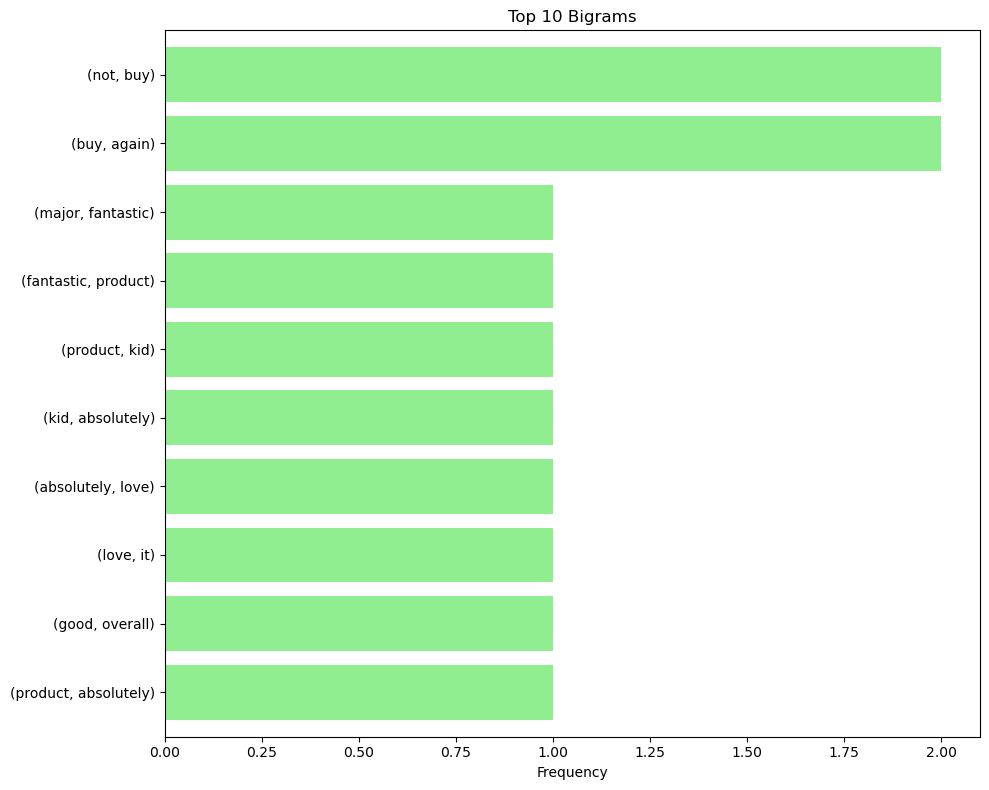

In [28]:
# TODO: Plot the top 10 bigrams as a horizontal bar chart
bigrams[0:10].sort_values().plot.barh(color= "lightgreen", width = 0.8, figsize = (10,8))
plt.title('Top 10 Bigrams')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

## Bonus Challenge — Positive vs Negative Reviews

Split the data into positive reviews (Rating >= 4) and negative reviews (Rating <= 2).
Find the top 5 unigrams in each group. Are the most common words different?

In [29]:
# TODO: Filter positive reviews (Rating >= 4) and negative reviews (Rating <= 2)
positive = data[data['Rating'] >= 4]
negative = data[data['Rating'] <= 2]

# TODO: Flatten tokens for each group
pos_tokens = sum(positive['Review_lemmatized'], [])
neg_tokens = sum(negative['Review_lemmatized'], [])

# TODO: Get top 5 unigrams for each and print them
pos_unigrams = pd.Series(nltk.ngrams(pos_tokens, 1)).value_counts()
neg_unigrams = pd.Series(nltk.ngrams(neg_tokens, 1)).value_counts()

print("Top 5 Positive Review Words:")
print(pos_unigrams[:5])

print("\nTop 5 Negative Review Words:")
print(neg_unigrams[:5])

Top 5 Positive Review Words:
(product,)     3
(great,)       3
(purchase,)    2
(quality,)     2
(shipping,)    2
Name: count, dtype: int64

Top 5 Negative Review Words:
(not,)          4
(buy,)          2
(terrible,)     1
(would,)        1
(different,)    1
Name: count, dtype: int64
